# Customer Segmentation

#### Mục lục 

| Phần | Nội dung |
|---|---|
| **1. Kiểm tra chất lượng dữ liệu** | kiểm tra dữ liệu thiếu, trùng lặp, phân phối các cột |
| **2. Chuẩn hoá** | đưa các trục phân cụm về cùng thang đo bằng `StandardScaler` (mean 0, std 1)  |
| **3. Chọn K** | **ràng buộc trước** (`min_share` ≥ 5%, `ari_2_seed` ≥ 0,90), rồi mới lấy `sil_gap` lớn nhất — silhouette thật trừ silhouette trên dữ liệu null (hoán vị từng cột để phá quan hệ giữa các biến) |
| ↳ *Elbow method* | tiêu chí thứ hai để đối chiếu chéo: inertia theo K, điểm gãy xác định bằng **kneedle**  |
| **4. Phân cụm** | chạy KMeans với K đã chọn, gán nhãn cụm cho từng rider |
| **5. Xây dựng hồ sơ (persona) cho từng cluster** | mô tả từng cụm bằng z-score các trục phân cụm, rồi đối chiếu với các trục không dùng để chia |
| **6. Chọn nhóm target và xuất kết quả** | gán tên persona tự động theo trục đặc trưng, chọn nhóm làm target, xuất 3 file CSV |
| ↳ *Diễn giải 3 cụm* | chốt chọn **Cụm 2** cho A/B test và lý do loại hai cụm còn lại |

## SET UP

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

SEED = 42
SRC = (r"C:\Users\Linh\Desktop\Growth & Experimentation Project for Ride-Hailing "
       r"Promotions\02. Synthetic_data\output\customer_features_final.csv")

df = pd.read_csv(SRC)
print(f"{len(df):,} rider x {df.shape[1]} cot")
display(df.head())

20,000 rider x 14 cot


,user_id,age,gender,home_borough,total_rides,recency_days,typical_distance,route_entropy,pct_airport,pref_time_bucket,weekend_ratio,pct_flex_payment,pct_tip_rate,avg_fare
0,1,19,Male,Manhattan,25,3,1.20,3.218876,0.000000,evening,0.360000,0.160000,0.271971,11.293
1,2,28,Other,Queens,13,1,3.01,2.564949,0.307692,morning,0.230769,0.230769,0.154094,42.771
2,3,30,Female,Manhattan,24,2,0.98,3.062529,0.125000,evening,0.083333,0.083333,0.323680,14.534
3,4,20,Male,Queens,34,2,3.27,3.526361,0.176471,midday,0.411765,0.264706,0.201018,30.315
4,5,42,Female,Manhattan,11,7,1.33,2.397895,0.000000,midday,0.363636,0.181818,0.262834,15.875


## 1. Kiểm tra chất lượng dữ liệu

In [5]:
# Kiểm tra giá trị thiếu, dòng trùng lặp và user_id trùng
print(f"gia tri thieu        : {df.isnull().sum().sum()}")
print(f"dong trung lap hoan toan: {df.duplicated().sum()}")
print(f"user_id trung        : {df.user_id.duplicated().sum()}")

# Kiểm tra các biến số lượng và phân phối
CHECK = ["total_rides", "recency_days", "typical_distance", "route_entropy",
         "pct_airport", "weekend_ratio", "pct_flex_payment", "pct_tip_rate", "avg_fare"]
display(df[CHECK].describe().round(3))

# Kiểm tra phân phối các biến phân loại
for c in ["gender", "home_borough", "pref_time_bucket"]:
    print(f"\n{c}:")
    print((df[c].value_counts(normalize=True) * 100).round(1).to_string())

gia tri thieu        : 0
dong trung lap hoan toan: 0
user_id trung        : 0


,total_rides,recency_days,typical_distance,route_entropy,pct_airport,weekend_ratio,pct_flex_payment,pct_tip_rate,avg_fare
count,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000
mean,22.421,14.163,2.861,2.795,0.078,0.295,0.265,0.242,21.331
std,16.173,22.795,2.743,0.873,0.133,0.155,0.162,0.063,9.880
min,1.000,0.000,0.100,0.000,0.000,0.000,0.000,0.000,3.700
25%,11.000,1.000,1.300,2.398,0.000,0.200,0.167,0.213,14.332
50%,19.000,4.000,1.868,2.944,0.000,0.286,0.250,0.247,19.020
75%,30.000,12.000,2.975,3.367,0.105,0.374,0.348,0.278,25.218
max,203.000,90.000,45.505,5.212,1.000,1.000,1.000,1.000,182.710



gender:
gender
Other     34.2
Female    33.0
Male      32.8

home_borough:
home_borough
Manhattan    81.0
Queens       16.5
Brooklyn      2.2
Bronx         0.3
Unknown       0.0

pref_time_bucket:
pref_time_bucket
evening       33.6
midday        31.0
late_night    18.7
morning       16.7


## 2. Chuẩn hoá

`StandardScaler` đưa mỗi cột về trung bình 0, độ lệch chuẩn 1

In [6]:
from sklearn.preprocessing import StandardScaler

# Các biến được chọn để phân cụm
CLUSTER_FEATURES = ["pct_tip_rate", "pct_flex_payment",
                    "pct_airport", "weekend_ratio"]

# Chuẩn hóa dữ liệu trước khi phân cụm
X = StandardScaler().fit_transform(df[CLUSTER_FEATURES].to_numpy(dtype=float))
print("Ma tran cluster:", X.shape)
print("mean ~ 0:", np.abs(X.mean(0)).max().round(6), " | std ~ 1:", X.std(0).round(4))

Ma tran cluster: (20000, 4)
mean ~ 0: 0.0  | std ~ 1: [1. 1. 1. 1.]


## 3. Chọn K

Chọn K theo hai bước, **ràng buộc trước — tối ưu sau**:

**Bước 1 —  Một K chỉ được xét tiếp nếu thoả cả hai**:

| Ràng buộc | Ngưỡng | Giải thích |
|---|---|---|
| `min_share` | ≥ 5% | cụm nhỏ hơn thế thì không đủ quy mô chạy chiến dịch riêng |
| `ari_2_seed` | ≥ 0,90 | hai seed khởi tạo khác nhau phải ra gần như cùng kết quả, nếu không thì kết quả là ngẫu nhiên của thuật toán |

**Bước 2 — trong số còn lại, lấy `sil_gap` lớn nhất.**

`sil_gap = silhouette thật − silhouette null`. Dữ liệu **null** dựng bằng cách hoán vị độc lập từng cột: giữ nguyên phân phối của mỗi biến nhưng phá hết quan hệ giữa các biến, nên không còn cụm nào tồn tại. 

In [14]:
# Dữ liệu null làm baseline: hoán vị độc lập từng cột.
#   - giữ nguyên phân phối từng biến
#   - phá hết quan hệ giữa các biến  -> không còn cluster thực sự nào nữa
# Nếu KMeans trên dữ liệu thật chỉ tốt ngang tren null thi cụm tim duoc la do ngau nhien.
def null_matrix(X, seed=0):
    rng = np.random.default_rng(seed)
    return np.column_stack([rng.permutation(X[:, j]) for j in range(X.shape[1])])


MIN_SHARE = 0.05   # cum nho nhat phai >= 5% population
MIN_ARI   = 0.90   # hai seed khác nhau phải cho ra phân cụm tương đồng nhau (ARI >= 0.9)

# Chọn k dựa trên các chỉ số: silhouette, inertia, ARI, min_share
def choose_k(X, k_range=range(2, 7), seed=SEED, sil_n=8000, n_null=10):
    """
        Bang danh gia K.
    """
    rng = np.random.default_rng(0)
    sub = rng.choice(len(X), min(sil_n, len(X)), replace=False)
    NULLS = [null_matrix(X, seed + 1000 * b) for b in range(n_null)]

    rows = []
    # Lặp qua các giá trị k để tính toán các chỉ số
    for k in k_range:
        km = KMeans(k, n_init=10, random_state=seed).fit(X)

        # silhouette tren tung tap null
        sn = np.array([
            silhouette_score(Xn[sub],
                             KMeans(k, n_init=10, random_state=seed).fit(Xn).labels_[sub])
            for Xn in NULLS])

        # do on dinh: cung K, hai seed khoi tao khac nhau
        a = KMeans(k, n_init=10, random_state=seed + 1).fit_predict(X)
        b = KMeans(k, n_init=10, random_state=seed + 2).fit_predict(X)

        rows.append({
            "k": k,
            "silhouette": silhouette_score(X[sub], km.labels_[sub]),
            "silhouette_null": sn.mean(),
            "null_sd": sn.std(ddof=1),
            "inertia": km.inertia_,
            "ari_2_seed": adjusted_rand_score(a, b),
            "min_share": pd.Series(km.labels_).value_counts(normalize=True).min(),
        })

    # Tạo DataFrame 
    t = pd.DataFrame(rows)
    t["sil_gap"] = t.silhouette - t.silhouette_null
    t["gap_se"]  = t.null_sd / np.sqrt(n_null)          # sai so cua chinh gap
    return t


ktab = choose_k(X)

# Chon K: Lọc k theo ràng buộc trước, sau đó chọn K tốt nhất dựa trên sil_gap lớn nhất
_ok  = ktab[(ktab.min_share >= MIN_SHARE) & (ktab.ari_2_seed >= MIN_ARI)]
_bad = ktab[~ktab.k.isin(_ok.k)]
assert len(_ok), f"khong con K nao thoa min_share>={MIN_SHARE} va ari>={MIN_ARI}"

# Chọn K tốt nhất dựa trên sil_gap lớn nhất
BEST_K = int(_ok.loc[_ok.sil_gap.idxmax(), "k"])

display(ktab.round(4))
# Hiển thị các K không đạt tiêu chí
if len(_bad):
    for _, r in _bad.iterrows():
        why = []
        # Xác định lý do loại bỏ K
        if r.min_share < MIN_SHARE:
            why.append(f"cum nho nhat {r.min_share:.2%} < {MIN_SHARE:.0%}")
        if r.ari_2_seed < MIN_ARI:
            why.append(f"ari {r.ari_2_seed:.3f} < {MIN_ARI}")
        print(f"K = {int(r.k)}: LOAI — {'; '.join(why)}")

# Hiển thị kết quả chọn K
print(f"\nCon lai {sorted(_ok.k.tolist())} -> chon K = {BEST_K} "
      f"(sil_gap {ktab.loc[ktab.k == BEST_K, 'sil_gap'].iloc[0]:.4f} "
      f"+/- {ktab.loc[ktab.k == BEST_K, 'gap_se'].iloc[0]:.4f})")

# Hiển thị các K không đạt tiêu chí
_r2 = _ok[_ok.k != BEST_K].nlargest(1, "sil_gap").iloc[0]
_g1 = ktab.loc[ktab.k == BEST_K, "sil_gap"].iloc[0]

,k,silhouette,silhouette_null,null_sd,inertia,ari_2_seed,min_share,sil_gap,gap_se
0,2,0.3405,0.3190,0.0039,63890.1819,0.9991,0.2203,0.0216,0.0012
1,3,0.2484,0.2005,0.0079,52228.5722,0.9751,0.1304,0.0479,0.0025
2,4,0.2197,0.1984,0.0043,45666.2030,0.9979,0.1131,0.0213,0.0014
3,5,0.2218,0.2140,0.0031,40444.1622,0.9986,0.0153,0.0078,0.0010
4,6,0.2066,0.1917,0.0024,37351.6941,0.9735,0.0151,0.0149,0.0008


K = 5: LOAI — cum nho nhat 1.53% < 5%
K = 6: LOAI — cum nho nhat 1.51% < 5%

Con lai [2, 3, 4] -> chon K = 3 (sil_gap 0.0479 +/- 0.0025)


**Bước 1 loại K = 5 và K = 6** — cụm nhỏ nhất chỉ 1,53% và 1,51%, tức khoảng 300 rider, quá nhỏ để chạy chiến dịch. 

**Bước 2, trong số K = 2 · 3 · 4 còn lại:**

| K | silhouette | null (TB 10 lần) | `sil_gap` | `gap_se` |
|---|---|---|---|---|
| 2 | 0,3405 | 0,3190 | 0,0216 | 0,0012 |
| **3** | 0,2484 | 0,2005 | **0,0479** | 0,0025 |
| 4 | 0,2197 | 0,1984 | 0,0213 | 0,0014 |

Nếu chỉ nhìn **silhouette thô** thì phải chọn **K = 2** — 0,3405 là cao nhất bảng. Nhưng dữ liệu đã xáo trộn hoàn toàn cũng đạt 0,3190, tức **93,7% con số đó là do ngẫu nhiên**; phần cấu trúc thật chỉ còn 0,0216. K = 3 có silhouette thấp hơn nhưng phần vượt baseline lại lớn nhất.

**K = 3:** `min_share` 13,04% (đủ chạy chiến dịch) · `ari_2_seed` 0,975 (chạy lại ra gần như cùng kết quả).

#### Visualize kết quả lựa chọn số lượng cluster K (Silhouette)

- Input:
    - k: số lượng cluster
    - silhouette: silhouette score trên dữ liệu thật
    - silhouette_null: silhouette score trên dữ liệu null
    - sil_gap: silhouette - silhouette_null

- Ouput: 
    - BEST_K: K được chọn dựa trên sil_gap lớn nhất.


    

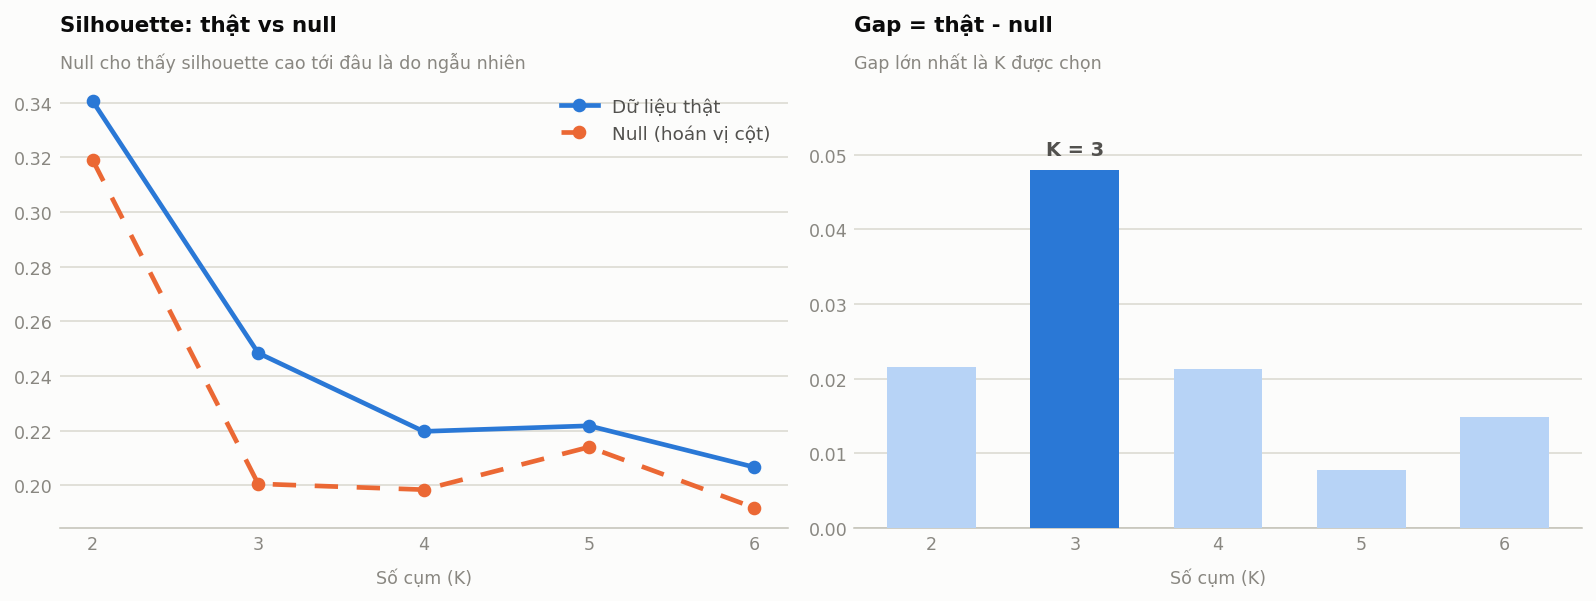

In [8]:
# Màu cho biểu đồ
SURFACE, INK, SECOND, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SERIES, ALT     = "#e1e0d9", "#c3c2b7", "#2a78d6", "#eb6834"

# Tạo figure gồm 2 biểu đồ:
# 1. Silhouette thật vs null
# 2. Silhouette gap theo K
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), dpi=140)
fig.patch.set_facecolor(SURFACE)

# Biểu đồ 1: Silhouette score của dữ liệu thật và dữ liệu null
ax = axes[0]; ax.set_facecolor(SURFACE)

# Silhouette trên dữ liệu thật. Cho biết mức độ tách biệt giữa các cluster với dữ liệu gốc.
ax.plot(ktab.k, ktab.silhouette, color=SERIES, lw=2.4, marker="o", ms=6,
        zorder=4, label="Dữ liệu thật")

# Silhouette trên dữ liệu null. Dữ liệu null được tạo bằng cách hoán vị độc lập từng feature để phá quan hệ giữa các biến.
ax.plot(ktab.k, ktab.silhouette_null, color=ALT, lw=2.4, marker="o", ms=6,
        ls=(0, (5, 4)), zorder=4, label="Null (hoán vị cột)")

# So sánh silhouette thật và baseline random.
ax.set_title("Silhouette: thật vs null", color=INK, fontsize=11,
             fontweight="bold", loc="left", pad=26)
ax.text(0, 1.02, "Null cho thấy silhouette cao tới đâu là do ngẫu nhiên",
        transform=ax.transAxes, color=MUTED, fontsize=9, va="bottom")

# Hiển thị
leg = ax.legend(frameon=False, fontsize=9.5, loc="upper right")
for t in leg.get_texts(): t.set_color(SECOND)


# Biểu đồ 2: Silhouette gap = silhouette thật - silhouette null
ax = axes[1]; ax.set_facecolor(SURFACE)
# Vẽ bar chart của silhouette gap. Gap càng lớn: => cluster thật càng vượt baseline random. 
bars = ax.bar(ktab.k, ktab.sil_gap, color=[SERIES if k == BEST_K else "#b7d3f6"
                                           for k in ktab.k], width=0.62, zorder=3)
ax.annotate(f"K = {BEST_K}", xy=(BEST_K, ktab.sil_gap.max()),
            xytext=(0, 6), textcoords="offset points", ha="center", va="bottom",
            color=SECOND, fontsize=10, fontweight="bold")
ax.set_title("Gap = thật - null", color=INK, fontsize=11,
             fontweight="bold", loc="left", pad=26)
ax.text(0, 1.02, "Gap lớn nhất là K được chọn", transform=ax.transAxes,
        color=MUTED, fontsize=9, va="bottom")
ax.set_ylim(0, ktab.sil_gap.max() * 1.25)

# Format chung cho cả hai biểu đồ
for ax in axes:
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color=GRID, lw=1); ax.xaxis.grid(False)
    for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(AXIS)
    ax.tick_params(colors=MUTED, length=0, labelsize=9)
    ax.set_xlabel("Số cụm (K)", color=MUTED, fontsize=9, labelpad=8)
    ax.set_xticks(ktab.k)

plt.tight_layout(); plt.show()

#### Elbow method — đối chiếu chéo với `sil_gap`

In [17]:
# Tính inertia cho từng K
K_ELBOW = [1] + list(ktab.k)
inertia = [KMeans(k, n_init=10, random_state=SEED).fit(X).inertia_ for k in K_ELBOW]

# Tìm điểm elbow bằng phương pháp Kneedle: điểm có khoảng cách xa nhất tới đường nối đầu-cuối.
def kneedle(ks, ine):
    """Diem gay = xa nhat toi day cung noi diem dau va diem cuoi (hai truc da chuan hoa)."""
    kx, ky = np.array(ks, float), np.asarray(ine, float)
    # Chuẩn hoá về [0,1]
    xn = (kx - kx.min()) / (kx.max() - kx.min())
    yn = (ky - ky.min()) / (ky.max() - ky.min())
    # Tính khoảng cách từ mỗi điểm tới đường thẳng nối điểm đầu và điểm cuối
    vx, vy = xn[-1] - xn[0], yn[-1] - yn[0]
    # Khoảng cách từ điểm (xn, yn) tới đường thẳng nối (xn[0], yn[0]) và (xn[-1], yn[-1])
    d = np.abs(vx * (yn - yn[0]) - vy * (xn - xn[0])) / np.hypot(vx, vy)
    return int(kx[d.argmax()]), d

# Tạo DataFrame hiển thị kết quả Elbow
kx, ky = np.array(K_ELBOW, float), np.array(inertia, float)
K_ELB, dist = kneedle(K_ELBOW, inertia)

elb = pd.DataFrame({"k": kx.astype(int), 
                    "khoang cach toi day cung": dist})
display(elb.round(4))

_t2 = elb.nlargest(2, "khoang cach toi day cung")
print(f"Elbow (kneedle) = K {K_ELB}")

,k,khoang cach toi day cung
0,1,0.0000
1,2,0.1257
2,3,0.1776
3,4,0.1450
4,5,0.0901
5,6,0.0000


Elbow (kneedle) = K 3


#### Visualize kết quả lựa chọn số lượng cluster K (Elbow)

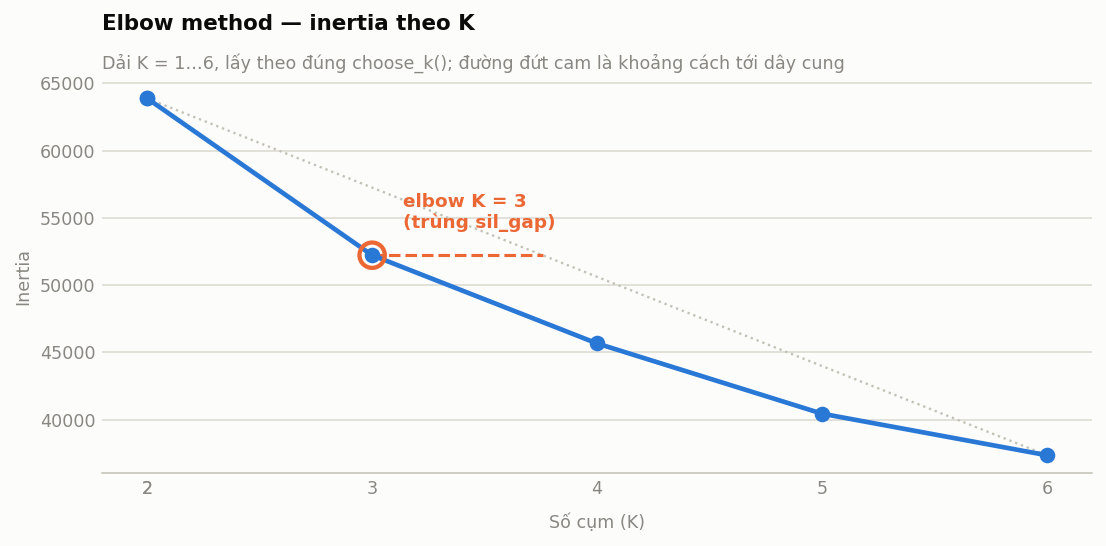

In [ ]:
# Vẽ biểu đồ Elbow: inertia theo K
fig, ax = plt.subplots(figsize=(8, 4.0), dpi=140, facecolor=SURFACE)
ax.set_facecolor(SURFACE)

# Vẽ đường nối điểm đầu và điểm cuối
ax.plot([kx[0], kx[-1]], [ky[0], ky[-1]], color=AXIS, lw=1.2, ls=":", zorder=2)
ax.plot(kx, ky, color=SERIES, lw=2.4, marker="o", ms=7, zorder=4)

# Vẽ đường từ điểm elbow tới đường nối đầu-cuối
_i = int(dist.argmax())
_t = ((kx[_i] - kx[0]) * (kx[-1] - kx[0]) + (ky[_i] - ky[0]) * (ky[-1] - ky[0])) / \
     ((kx[-1] - kx[0]) ** 2 + (ky[-1] - ky[0]) ** 2)
ax.plot([kx[_i], kx[0] + _t * (kx[-1] - kx[0])],
        [ky[_i], ky[0] + _t * (ky[-1] - ky[0])],
        color=ALT, lw=1.6, ls="--", zorder=3)
ax.scatter([K_ELB], [ky[_i]], s=170, facecolor="none", edgecolor=ALT, lw=2.2, zorder=5)
ax.annotate(f"elbow K = {K_ELB}\n(trùng sil_gap)" if K_ELB == BEST_K else f"elbow K = {K_ELB}",
            xy=(K_ELB, ky[_i]), xytext=(16, 14), textcoords="offset points",
            color=ALT, fontsize=9.5, fontweight="bold")

# Format cho biểu đồ
ax.set_title("Elbow method — inertia theo K", color=INK, fontsize=11,
             fontweight="bold", loc="left", pad=26)
ax.text(0, 1.02, "Dải K = 1…6, lấy theo đúng choose_k(); đường đứt cam là khoảng cách tới dây cung",
        transform=ax.transAxes, color=MUTED, fontsize=9, va="bottom")
ax.set_xlabel("Số cụm (K)", color=MUTED, fontsize=9, labelpad=8)
ax.set_ylabel("Inertia", color=MUTED, fontsize=9)
ax.set_xticks(K_ELBOW)
ax.set_axisbelow(True)
ax.yaxis.grid(True, color=GRID, lw=1); ax.xaxis.grid(False)
for sp in ("top", "right", "left"):
    ax.spines[sp].set_visible(False)
ax.spines["bottom"].set_color(AXIS)
ax.tick_params(colors=MUTED, length=0, labelsize=9)
plt.tight_layout(); plt.show()

## 4. Phân cụm

Huấn luyện mô hình KMeans với số cluster tối ưu

`random_state=SEED` để chạy lại ra đúng kết quả cũ.

In [11]:
# n_init=10: chạy thuật toán 10 lần với các tâm khởi tạo khác nhau và chọn kết quả có inertia nhỏ nhất.
# random_state: cố định kết quả để tái lập được.
km = KMeans(BEST_K, n_init=10, random_state=SEED).fit(X)
df["cluster"] = km.labels_

size = (df.cluster.value_counts(normalize=True).sort_index() * 100).round(2)
print("Quy mo tung cum (%):"); print(size.to_string())

Quy mo tung cum (%):
cluster
0    54.73
1    13.04
2    32.23


## 5. Xây dựng hồ sơ (persona) cho từng cluster

| Loại | Gồm | Dùng để |
|---|---|---|
| **Trục phân cụm** | 4 tỷ lệ hành vi | chia nhóm |
| **Trục mô tả** | `typical_distance`, `avg_fare`, `pref_time_bucket`, `home_borough` | **chỉ** để mô tả, không vào KMeans |


In [18]:
# Các feature dùng để mô tả persona
PROFILE_FEATURES = ["typical_distance", "avg_fare", 
                    "pref_time_bucket", "home_borough"]

# z = (x - mean) / std
# Mục đích: So sánh từng cluster với mức trung bình của toàn bộ rider.
# z > 0 : cao hơn trung bình
# z < 0 : thấp hơn trung bình
z = (df[CLUSTER_FEATURES] - df[CLUSTER_FEATURES].mean()) / df[CLUSTER_FEATURES].std()
z["cluster"] = df.cluster

# Tính giá trị Z-score trung bình của từng cluster
prof = z.groupby("cluster").mean().round(2)
prof.columns = [f"z_{c}" for c in prof.columns]

# Quy mô của từng cluster
# n       : số rider
# share_% : tỷ lệ rider trong toàn bộ dữ liệu
prof.insert(0, "share_%", (df.cluster.value_counts(normalize=True) * 100).round(2))
prof.insert(0, "n", df.cluster.value_counts())

# Tính giá trị trung bình của các feature
num = [c for c in PROFILE_FEATURES if pd.api.types.is_numeric_dtype(df[c])]
prof = prof.join(df.groupby("cluster")[num].mean().round(2))

# Thêm số chuyến trung bình của từng cluster
prof = prof.join(df.groupby("cluster")[["total_rides"]].mean().round(2)
                 .rename(columns={"total_rides": "rides_TB"}))

# Hiển thị bảng hồ sơ của từng cluster
display(prof.sort_index())

# Phân bố khung giờ yêu thích của từng cluster. 
# Mỗi hàng được chuẩn hóa về 100% để xem rider trong từng cluster thường đi vào thời điểm nào.
print("Khung gio troi cua tung cum (%):")
display((pd.crosstab(df.cluster, df.pref_time_bucket, normalize="index") * 100).round(1))

,n,share_%,z_pct_tip_rate,z_pct_flex_payment,z_pct_airport,z_weekend_ratio,typical_distance,avg_fare,rides_TB
cluster,,,,,,,,,
0,10946,54.73,0.42,-0.43,-0.36,-0.28,1.70,16.51,23.12
1,2608,13.04,-0.78,-0.42,2.04,-0.20,7.32,38.26,21.51
2,6446,32.23,-0.41,0.90,-0.21,0.56,3.02,22.67,21.61


Khung gio troi cua tung cum (%):


pref_time_bucket,evening,late_night,midday,morning
cluster,,,,
0,38.0,10.2,35.1,16.6
1,32.4,15.7,35.1,16.8
2,26.4,34.3,22.4,16.8


| Persona | Quy mô | Chia theo (z-score trên 4 trục phân cụm) | Mô tả bằng trục KHÔNG dùng để chia |
|---|---|---|---|
| Nội đô ngày thường, tip cao *(cụm 0)* | 10.946 · 54,7% | tip `+0,42`, ba trục còn lại đều âm | cự ly **1,70** dặm · cước **16,51** — thấp nhất · trội `evening` 38,0% |
| Sân bay / đường dài *(cụm 1)* | 2.608 · 13,0% | sân bay `+2,04` — trục tách bạch nhất | cự ly **7,32** · cước **38,26** — cao nhất, gấp hơn 2 lần |
| Cuối tuần, trả Flex *(cụm 2)* | 6.446 · 32,2% | Flex `+0,90`, cuối tuần `+0,56`, tip `−0,41` | cự ly 3,02 · cước 22,67 · trội `late_night` 34,3%, gấp 2- 3 lần hai cụm kia |

## 6. Chọn nhóm target và xuất kết quả

In [13]:
# Lưu data các cụm vào file
import os

# Tạo thư mục output 
OUTDIR = (r"c:/Users/Linh/Desktop/Growth & Experimentation Project for Ride-Hailing "
          r"Promotions/03. Segmentation/outputs")
os.makedirs(OUTDIR, exist_ok=True)

# Tính Z-score của các feature dùng cho clustering
zp = (df[CLUSTER_FEATURES] - df[CLUSTER_FEATURES].mean()) / df[CLUSTER_FEATURES].std()
zp["cluster"] = df.cluster

# Hồ sơ Z-score trung bình của từng cluster
zprof = zp.groupby("cluster").mean().round(3)
zprof.columns = [f"z_{c}" for c in zprof.columns]

# Định nghĩa đặc trưng đại diện cho từng persona.
# Cluster có Z-score cao nhất ở đặc trưng nào sẽ được gán tên tương ứng.
SIGNATURE = {
    "z_pct_tip_rate":     "Khach noi do ngay thuong, tip cao",
    "z_pct_flex_payment": "Khach cuoi tuan, tra Flex, tip thap",
    "z_pct_airport":      "Khach san bay / duong dai",
}

# Gán tên persona cho từng cluster.
NAMES, taken = {}, set()
for axis, name in SIGNATURE.items():
    con_lai = [i for i in zprof.index if i not in taken]
    k = int(zprof.loc[con_lai, axis].idxmax())
    NAMES[k] = name
    taken.add(k)
assert len(NAMES) == len(zprof), "so cum khong khop so ten"

TARGET_NAME    = "Khach cuoi tuan, tra Flex, tip thap"   # nhay gia -> chon de A/B test
TARGET_CLUSTER = [k for k, v in NAMES.items() if v == TARGET_NAME][0]

# Hiển thị kết quả gán persona và cluster mục tiêu.
print("Gan nhan tu dong theo truc dac trung:")
for k in sorted(NAMES):
    print(f"   cum {k} -> {NAMES[k]}")
print(f"TARGET_CLUSTER = {TARGET_CLUSTER}\n")

# 1. Nhan cap rider 
rider = df[["user_id"]].copy()
rider["cluster"]   = df.cluster
rider["persona"]   = df.cluster.map(NAMES)
rider["is_target"] = (df.cluster == TARGET_CLUSTER).astype(int)
rider.to_csv(os.path.join(OUTDIR, "rider_cluster.csv"), index=False)

# 2. Ho so tung cum: z-score cac truc phan cum 
out = zprof.copy()
out.insert(0, "share_%", (df.cluster.value_counts(normalize=True) * 100).round(2))
out.insert(0, "n", df.cluster.value_counts())
out.insert(0, "persona", out.index.map(NAMES))
out = out.join(df.groupby("cluster")[["total_rides", "typical_distance",
                                      "avg_fare", "weekend_ratio"]].mean().round(2))
out.sort_index().to_csv(os.path.join(OUTDIR, "cluster_profiles.csv"))

# 3. Toan bo feature cua nhom target
tg = df[df.cluster == TARGET_CLUSTER].drop(columns=["cluster"])
tg.to_csv(os.path.join(OUTDIR, "target_riders.csv"), index=False)

print(f"Da luu vao {OUTDIR}\n")
for fn in sorted(os.listdir(OUTDIR)):
    p = os.path.join(OUTDIR, fn)
    print(f"   {fn:<24} {os.path.getsize(p):>9,} bytes")

print(f"\nrider_cluster.csv : {len(rider):,} dong x {rider.shape[1]} cot")
print(f"target_riders.csv : {len(tg):,} rider thuoc Cum {TARGET_CLUSTER}")
print(f"\nQuy mo tung cum:")
for k in sorted(NAMES):
    n = int((df.cluster == k).sum())
    mark = "  <- TARGET" if k == TARGET_CLUSTER else ""
    print(f"   Cum {k}  {NAMES[k]:<46} {n:>6,}  ({n/len(df):>5.1%}){mark}")

Gan nhan tu dong theo truc dac trung:
   cum 0 -> Khach noi do ngay thuong, tip cao
   cum 1 -> Khach san bay / duong dai
   cum 2 -> Khach cuoi tuan, tra Flex, tip thap
TARGET_CLUSTER = 2



Da luu vao c:/Users/Linh/Desktop/Growth & Experimentation Project for Ride-Hailing Promotions/03. Segmentation/outputs

   cluster_profiles.csv           429 bytes
   rider_cluster.csv          915,741 bytes
   target_riders.csv          575,542 bytes

rider_cluster.csv : 20,000 dong x 4 cot
target_riders.csv : 6,446 rider thuoc Cum 2

Quy mo tung cum:
   Cum 0  Khach noi do ngay thuong, tip cao              10,946  (54.7%)
   Cum 1  Khach san bay / duong dai                       2,608  (13.0%)
   Cum 2  Khach cuoi tuan, tra Flex, tip thap             6,446  (32.2%)  <- TARGET


### Diễn giải 3 cụm

**Cụm 0 — Khách nội đô ngày thường, tip cao (54.7%, 10,946 rider)**
`z_pct_tip_rate = +0.42` cao nhất, cả ba trục còn lại đều âm: ít Flex (−0.43), ít sân bay (−0.36), ít cuối tuần (−0.28). Quãng đường 1.70 dặm và cước 16.51 — thấp nhất. Trội khung `evening` (38.0%) — cao nhất trong ba cụm — và `midday` (35.1%).
*Ý nghĩa:* đi lại nội đô trong giờ hành chính, chặng ngắn, giá trị mỗi chuyến thấp nhưng chịu tip. 

**Cụm 1 — Khách sân bay / đường dài (13.0%, 2,608 rider)**
`z_pct_airport = +2.04`, vượt xa mọi cụm khác. Quãng đường 7.32 dặm (gấp 4.3 lần cụm 0) và cước 38.26 — cao nhất. Tip thấp nhất (−0.78).
*Ý nghĩa:* nhóm nhỏ nhất nhưng doanh thu mỗi chuyến cao nhất.

**Cụm 2 — Khách cuối tuần, trả Flex, tip thấp (32.2%, 6,446 rider)**
Định danh bằng `z_pct_flex_payment = +0.90` đi kèm `z_weekend_ratio = +0.56` (tỷ lệ cuối tuần 0.38, cao nhất). Tip thấp (−0.41). Trội khung `late_night` 34.3% — cao hơn hẳn hai cụm kia (10.2% và 15.7%).
*Ý nghĩa:* nhu cầu đi chơi và về khuya, thanh toán linh hoạt, ít chịu tip.

**Chọn cụm cho A/B test: Cụm 2.** Với mục tiêu tăng incremental trips, cụm 2 là nhóm nhạy giá nhất — tỷ lệ trả Flex cao nhất cho thấy họ để tâm tới cách thanh toán, đi kèm tip dưới trung bình. Cụm 0 tuy đông hơn 70% nhưng đã đi đều đặn trong tuần, voucher dễ rơi vào chuyến vốn dĩ sẽ xảy ra. Cụm 1 thì nhu cầu gắn với lịch bay nên khó dịch chuyển bằng khuyến mãi.